In [1]:
# --------------------------------------------------------------------
# 1. Imports and settings
# --------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

In [11]:
# --------------------------------------------------------------------
# 2. Load the three essential CSV files
# --------------------------------------------------------------------
# We read train.csv, members_v3.csv, and transactions.csv.
# The dates in transactions.csv are parsed automatically.
# --------------------------------------------------------------------
DATA_DIR = "csv_files/"

trans_data = pd.read_csv(os.path.join(DATA_DIR, "mult_cohort_transaction_data.csv"), parse_dates = ["last_transaction_date", "cohort_cutoff_date"])

usage_data = pd.read_parquet(os.path.join(DATA_DIR, "mult_cohort_usage_data.parquet"))
usage_data["cohort_cutoff_date"] = pd.to_datetime(usage_data["cohort_cutoff_date"])

members = pd.read_csv(
    os.path.join(DATA_DIR, "members_v3.csv")
)

print("Train shape:", trans_data.shape)
print("Members shape:", members.shape)
print("Usage shape:", usage_data.shape)

Train shape: (16980367, 19)
Members shape: (6769473, 6)
Usage shape: (16980367, 9)


In [12]:
trans_data.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 16980367 entries, 0 to 16980366
Data columns (total 19 columns):
 #   Column                   Non-Null Count     Dtype         
---  ------                   --------------     -----         
 0   msno                     16980367 non-null  str           
 1   is_churn                 16980367 non-null  int64         
 2   num_transactions         16980367 non-null  int64         
 3   total_paid               16980367 non-null  int64         
 4   avg_plan_price           16980367 non-null  float64       
 5   total_auto_renew         16980367 non-null  int64         
 6   total_cancel             16980367 non-null  int64         
 7   last_payment_plan_days   16980367 non-null  int64         
 8   last_plan_list_price     16980367 non-null  int64         
 9   last_actual_amount_paid  16980367 non-null  int64         
 10  last_is_auto_renew       16980367 non-null  int64         
 11  last_transaction_date    16980367 non-null  datetime64[us]


In [14]:
trans_data.head(10)

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01
5,++3UnufK0Ka+brv8dKFZUpOV41Jk2uRLYSWIkT6Ff6c=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-08,0,24,24,7,4.806452,2015-02-01
6,++3Z+W8OPnpbHYfrKwqRKN1bF83XEbxjdYUolhGdHZg=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01
7,++4RuqBw0Ss6bQU4oMxaRlbBPoWzoEiIZaxPM04Y4+U=,0,1,129,129.0,1,0,30,129,129,1,2015-01-13,2015-02-13,0,19,19,12,4.161290,2015-02-01
8,++4cUL0b9CfW8cj0A/wfSxQc4k4fcVtWcLqk2UOdpKs=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01
9,++5XBxbJNz3idK9egVoGbWJ4xhGQu2MR0pSP0kL9DK4=,0,1,129,129.0,1,0,30,129,129,1,2015-01-18,2015-02-19,0,14,14,18,4.031250,2015-02-01


In [15]:
usage_data.info(show_counts = True)

<class 'pandas.DataFrame'>
Index: 16980367 entries, 0 to 875335
Data columns (total 9 columns):
 #   Column               Non-Null Count     Dtype        
---  ------               --------------     -----        
 0   msno                 16980367 non-null  str          
 1   cohort_cutoff_date   16980367 non-null  datetime64[s]
 2   days_since_last_use  14403986 non-null  float64      
 3   num_25_velocity      12964219 non-null  float64      
 4   num_75_velocity      12139370 non-null  float64      
 5   num_985_velocity     12113051 non-null  float64      
 6   num_100_velocity     13083010 non-null  float64      
 7   num_unq_velocity     13259308 non-null  float64      
 8   total_secs_velocity  13235233 non-null  float64      
dtypes: datetime64[s](1), float64(7), str(1)
memory usage: 2.0 GB


In [16]:
usage_data.head(10)

,msno,cohort_cutoff_date,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,GL0NCk+xsxjX69d9sDe4AajTs0Vn51iiViFCZTiNbDw=,2015-02-01,2.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,siClR1LyAUqVVH9bLKFt6F+FWjdqsaz8G8KI/drSSHE=,2015-02-01,0.0,0.607143,0.150000,0.428571,0.389956,0.522843,0.401507
2,BGrqaY1yM37j8ydHwU44l2SZqBh74Hy/ifqkTUhUOPI=,2015-02-01,0.0,0.393939,NaN,0.750000,0.425373,0.452830,0.430844
3,rk0lM3Zw7i61lrqLpX4hegBwH2GTsmn0j9MwdgTYrkM=,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,uRyp9+40qlzADBaSNdvF+jfZDiggmRefpSmWAxEfi1A=,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,tF57DWAPy5/lqbJcQyOmxswksUhLsLnNs120xA0OiIU=,2015-02-01,0.0,1.000000,0.000000,0.500000,0.254545,0.344262,0.308877
6,zLAVuiZa9Twb6/EJZu6ftCv+4U9XGuiDpRa5YIWMFHs=,2015-02-01,0.0,0.370370,0.454545,0.333333,0.520446,0.397476,0.500365
7,A/3mrEqScEKoowGelfNKYGOM2yVX753geehHFW0dySc=,2015-02-01,0.0,0.376238,0.478261,0.428571,0.403302,0.347107,0.387849
8,gHX/QfTB0vmsugbghbAWZcXiqElTILi03zvlUtgHOMs=,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2kaK2j3vHz1rkDTLjHU2VayrMaBhVXfegkGKMiCrgH4=,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
#We want to merge these three together into one massive data frame
members = pd.merge(trans_data, members, on = 'msno', how = 'left')
members = pd.merge(members, usage_data, on = ['msno', 'cohort_cutoff_date'], how = 'left')



In [18]:
members.head(10)

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date,city,bd,gender,registered_via,registration_init_time,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01,1.0,0.0,NaN,7.0,20140927.0,0.0,0.628527,0.592920,0.568966,0.493279,0.507880,0.494680
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01,15.0,32.0,male,3.0,20121217.0,0.0,0.670455,0.666667,0.500000,0.469307,0.490090,0.469975
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01,1.0,0.0,NaN,7.0,20131029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01,1.0,0.0,NaN,7.0,20140822.0,15.0,0.000000,NaN,NaN,0.000000,0.000000,0.000000
5,++3UnufK0Ka+brv8dKFZUpOV41Jk2uRLYSWIkT6Ff6c=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-08,0,24,24,7,4.806452,2015-02-01,10.0,27.0,male,7.0,20131109.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,++3Z+W8OPnpbHYfrKwqRKN1bF83XEbxjdYUolhGdHZg=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01,5.0,35.0,female,7.0,20120209.0,0.0,0.384615,0.600000,0.500000,0.414634,0.326923,0.353206
7,++4RuqBw0Ss6bQU4oMxaRlbBPoWzoEiIZaxPM04Y4+U=,0,1,129,129.0,1,0,30,129,129,1,2015-01-13,2015-02-13,0,19,19,12,4.161290,2015-02-01,1.0,0.0,NaN,7.0,20140714.0,2.0,0.360656,0.333333,0.000000,0.295181,0.302752,0.292404
8,++4cUL0b9CfW8cj0A/wfSxQc4k4fcVtWcLqk2UOdpKs=,0,1,149,149.0,1,0,30,149,149,1,2015-01-08,2015-02-09,0,24,24,8,4.656250,2015-02-01,15.0,28.0,male,7.0,20121009.0,1.0,0.588235,0.400000,0.214286,0.416964,0.521490,0.413965
9,++5XBxbJNz3idK9egVoGbWJ4xhGQu2MR0pSP0kL9DK4=,0,1,129,129.0,1,0,30,129,129,1,2015-01-18,2015-02-19,0,14,14,18,4.031250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
members.info(show_counts = True)

<class 'pandas.DataFrame'>
RangeIndex: 16980367 entries, 0 to 16980366
Data columns (total 31 columns):
 #   Column                   Non-Null Count     Dtype         
---  ------                   --------------     -----         
 0   msno                     16980367 non-null  str           
 1   is_churn                 16980367 non-null  int64         
 2   num_transactions         16980367 non-null  int64         
 3   total_paid               16980367 non-null  int64         
 4   avg_plan_price           16980367 non-null  float64       
 5   total_auto_renew         16980367 non-null  int64         
 6   total_cancel             16980367 non-null  int64         
 7   last_payment_plan_days   16980367 non-null  int64         
 8   last_plan_list_price     16980367 non-null  int64         
 9   last_actual_amount_paid  16980367 non-null  int64         
 10  last_is_auto_renew       16980367 non-null  int64         
 11  last_transaction_date    16980367 non-null  datetime64[us]


In [20]:
#To free up space, we delete the other dataframes
del trans_data
del usage_data

In [22]:
#The age column is going to be unstable across multiple cohorts as we do not have the exact birth date but rather
#the age when they pulled the member data, date unknown. So, we choose to drop the age feature.
members.drop(['bd'], inplace = True, axis = 1)

In [23]:
members.head()

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date,city,gender,registered_via,registration_init_time,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01,1.0,NaN,7.0,20140927.0,0.0,0.628527,0.592920,0.568966,0.493279,0.50788,0.494680
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01,15.0,male,3.0,20121217.0,0.0,0.670455,0.666667,0.500000,0.469307,0.49009,0.469975
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01,1.0,NaN,7.0,20131029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01,1.0,NaN,7.0,20140822.0,15.0,0.000000,NaN,NaN,0.000000,0.00000,0.000000


In [25]:
#There are some users who have a registration_init_time that is way after their first transaction. So, we drop this feature as we have access to how long since their first transaction
#as some indication of their time with the service
members.drop(['registration_init_time'], inplace = True, axis = 1)

KeyError: "['registration_init_time'] not found in axis"

In [26]:
members.head()

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date,city,gender,registered_via,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01,1.0,NaN,7.0,0.0,0.628527,0.592920,0.568966,0.493279,0.50788,0.494680
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01,15.0,male,3.0,0.0,0.670455,0.666667,0.500000,0.469307,0.49009,0.469975
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01,1.0,NaN,7.0,15.0,0.000000,NaN,NaN,0.000000,0.00000,0.000000


In [28]:
#We have multiple cohorts of data. we have cohorts for expiration dates in Feb 2015 - Feb 2017. Hence we have 25 cohorts. We will hold out the last two cohorts for final testing.
members_train = members.loc[members['cohort_cutoff_date'] < datetime(2016, 12, 1)]
members_test = members.loc[members['cohort_cutoff_date'] >= datetime(2016, 12, 1)]


In [30]:
#Sanity check
print(members_train.cohort_cutoff_date.max())
print(members_test.cohort_cutoff_date.min())

2016-11-01 00:00:00
2016-12-01 00:00:00


In [31]:
members_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 14363668 entries, 0 to 14363667
Data columns (total 29 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   msno                     str           
 1   is_churn                 int64         
 2   num_transactions         int64         
 3   total_paid               int64         
 4   avg_plan_price           float64       
 5   total_auto_renew         int64         
 6   total_cancel             int64         
 7   last_payment_plan_days   int64         
 8   last_plan_list_price     int64         
 9   last_actual_amount_paid  int64         
 10  last_is_auto_renew       int64         
 11  last_transaction_date    datetime64[us]
 12  last_expire              str           
 13  last_is_cancel           int64         
 14  days_since_first_trans   int64         
 15  days_since_last_trans    int64         
 16  days_to_expire           int64         
 17  avg_payment_per_day      float64    

In [32]:
members_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2616699 entries, 14363668 to 16980366
Data columns (total 29 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   msno                     str           
 1   is_churn                 int64         
 2   num_transactions         int64         
 3   total_paid               int64         
 4   avg_plan_price           float64       
 5   total_auto_renew         int64         
 6   total_cancel             int64         
 7   last_payment_plan_days   int64         
 8   last_plan_list_price     int64         
 9   last_actual_amount_paid  int64         
 10  last_is_auto_renew       int64         
 11  last_transaction_date    datetime64[us]
 12  last_expire              str           
 13  last_is_cancel           int64         
 14  days_since_first_trans   int64         
 15  days_since_last_trans    int64         
 16  days_to_expire           int64         
 17  avg_payment_per_day      float

## Now we explore the variables to see if they have correlation with is_churn

<Axes: xlabel='is_churn', ylabel='num_transactions'>

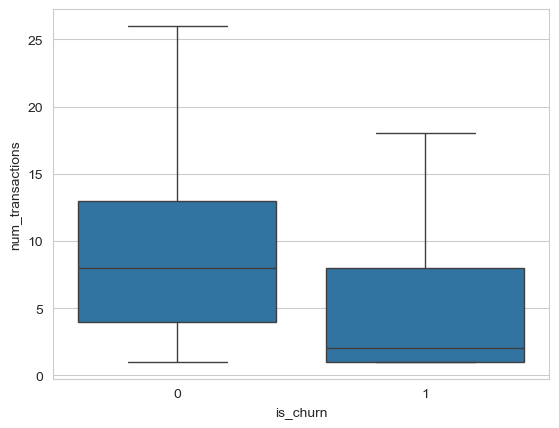

In [37]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_transactions', showfliers = False)

### There does seem to be some separation caused by num_transactions alone

<Axes: xlabel='is_churn', ylabel='total_paid'>

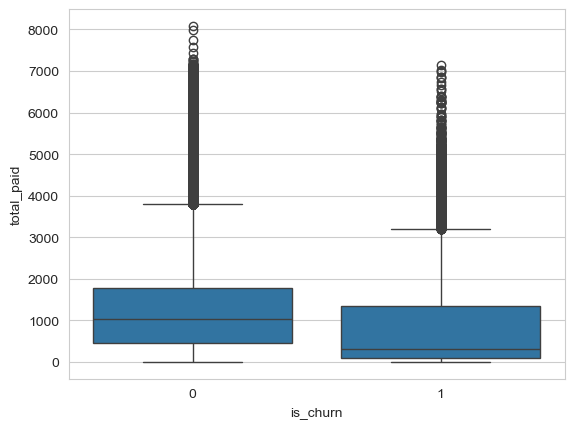

In [38]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_paid')

<Axes: xlabel='is_churn', ylabel='avg_plan_price'>

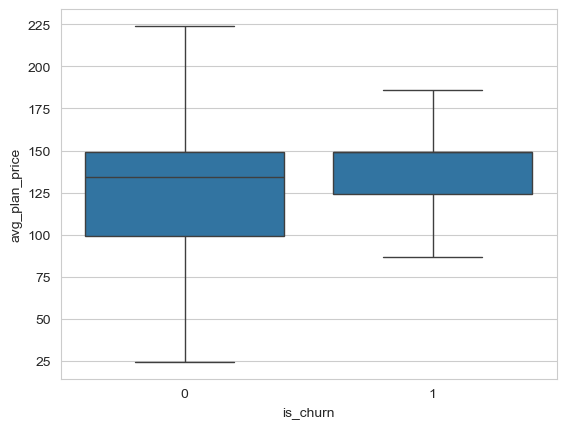

In [41]:
sns.boxplot(members_train, x = 'is_churn', y = 'avg_plan_price', showfliers = False)

<Axes: xlabel='is_churn', ylabel='last_plan_list_price'>

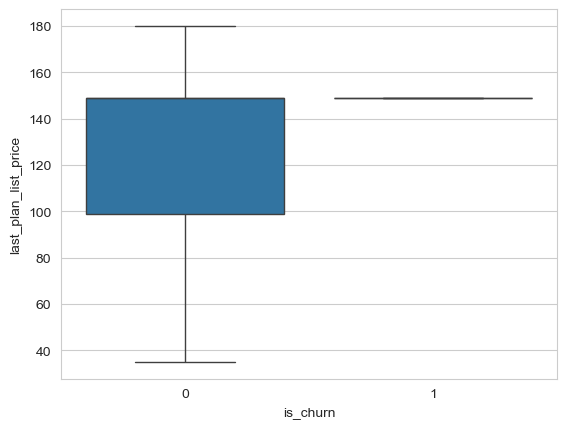

In [45]:
sns.boxplot(members_train, x = 'is_churn', y = 'last_plan_list_price', showfliers = False)

<Axes: xlabel='is_churn', ylabel='last_actual_amount_paid'>

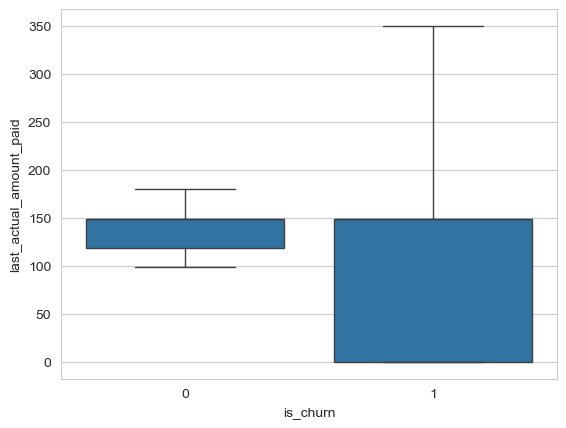

In [57]:
sns.boxplot(members_train, x = 'is_churn', y = 'last_actual_amount_paid', showfliers = False)

<Axes: xlabel='is_churn', ylabel='total_auto_renew'>

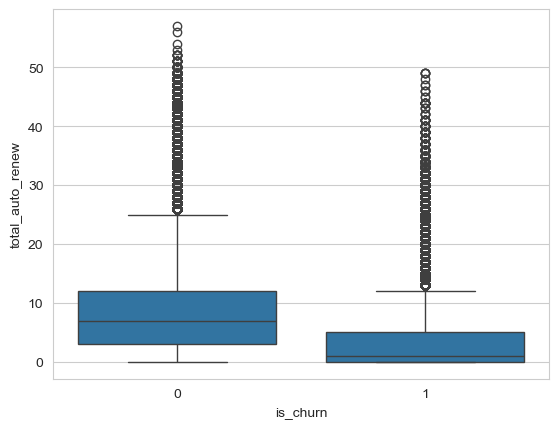

In [42]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_auto_renew')

In [51]:
print("is_churn and last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 1) & (members_train['is_churn'] == 1)].shape[0])
print("is_churn and not last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 0) & (members_train['is_churn'] == 1)].shape[0])

print("not is_churn and last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 1) & (members_train['is_churn'] == 0)].shape[0])
print("not is_churn and not last_is_auto_renew:", members_train.loc[(members_train['last_is_auto_renew'] == 0) & (members_train['is_churn'] == 0)].shape[0])

is_churn and last_is_auto_renew: 707868
is_churn and not last_is_auto_renew: 515680
not is_churn and last_is_auto_renew: 11572432
not is_churn and not last_is_auto_renew: 1567688


In [54]:
#Testing out a new feature... Ratio of auto_renew
members_train['ratio_auto_renew'] = members_train['total_auto_renew'] / members_train['num_transactions']


<Axes: xlabel='is_churn', ylabel='ratio_auto_renew'>

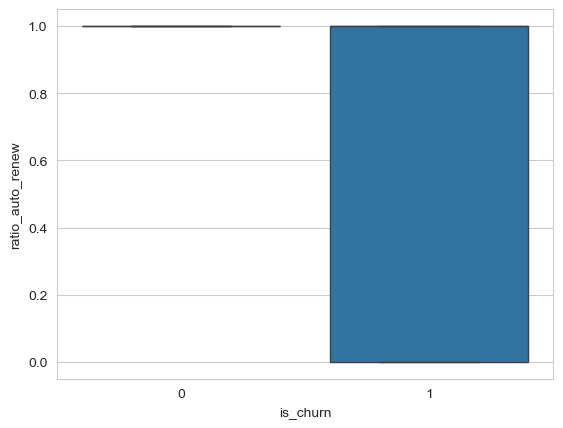

In [56]:
sns.boxplot(members_train, x = 'is_churn', y = 'ratio_auto_renew', showfliers = False)

<Axes: xlabel='is_churn', ylabel='total_cancel'>

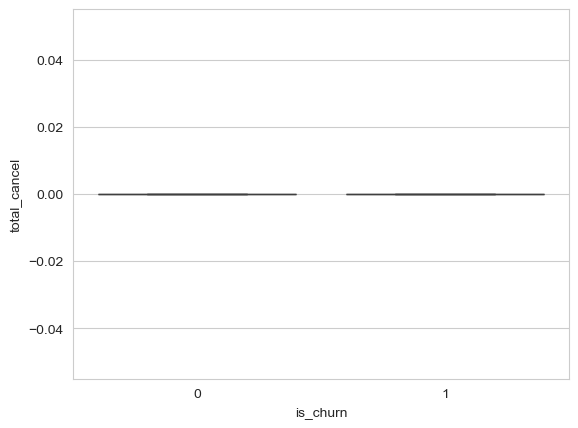

In [83]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_cancel', showfliers = False)

In [59]:
print("is_churn and last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 1) & (members_train['is_churn'] == 1)].shape[0])
print("is_churn and not last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 0) & (members_train['is_churn'] == 1)].shape[0])

print("not is_churn and last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 1) & (members_train['is_churn'] == 0)].shape[0])
print("not is_churn and not last_is_cancel:", members_train.loc[(members_train['last_is_cancel'] == 0) & (members_train['is_churn'] == 0)].shape[0])

is_churn and last_is_cancel: 181601
is_churn and not last_is_cancel: 1041947
not is_churn and last_is_cancel: 35853
not is_churn and not last_is_cancel: 13104267


In [60]:
#Testing out cancel ratio:
members_train['ratio_cancel'] = members_train['total_cancel'] / members_train['num_transactions']

<Axes: xlabel='is_churn', ylabel='ratio_cancel'>

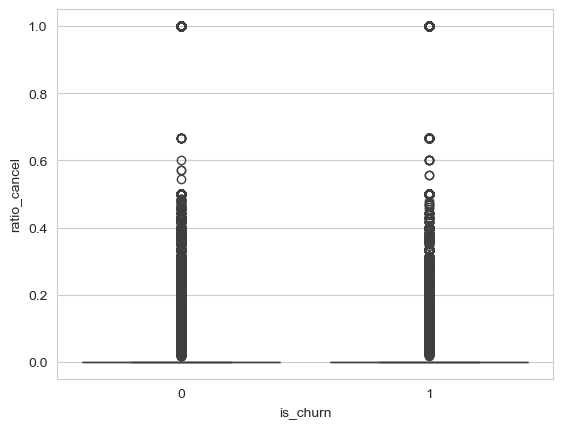

In [61]:
sns.boxplot(members_train, x = 'is_churn', y = 'ratio_cancel')

<Axes: xlabel='is_churn', ylabel='days_since_first_trans'>

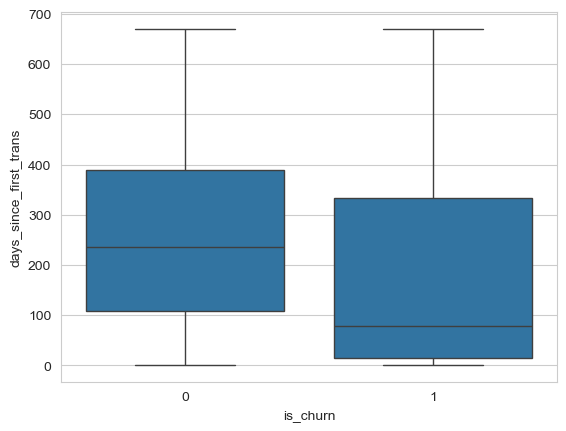

In [62]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_since_first_trans')

<Axes: xlabel='is_churn', ylabel='days_since_last_trans'>

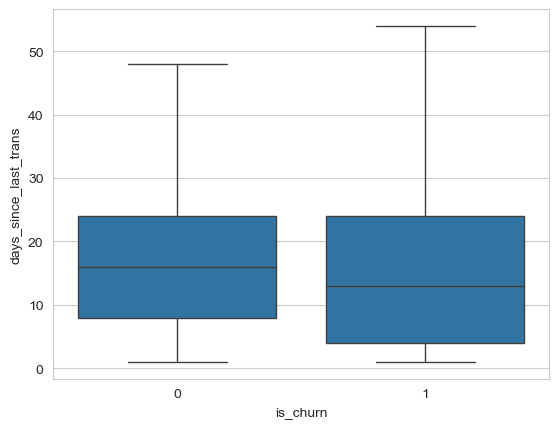

In [63]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_since_last_trans', showfliers = False)

<Axes: xlabel='is_churn', ylabel='avg_payment_per_day'>

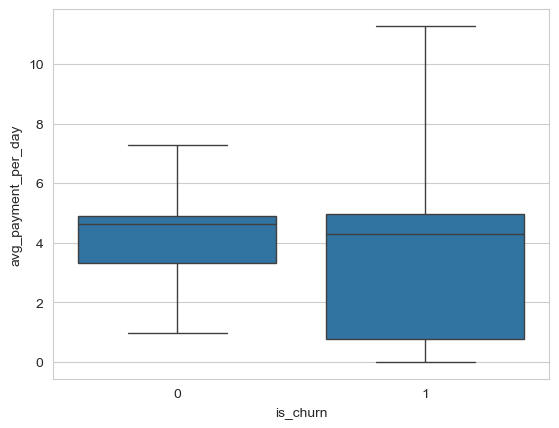

In [64]:
sns.boxplot(members_train, x = 'is_churn', y = 'avg_payment_per_day', showfliers = False)

<Axes: xlabel='is_churn', ylabel='days_to_expire'>

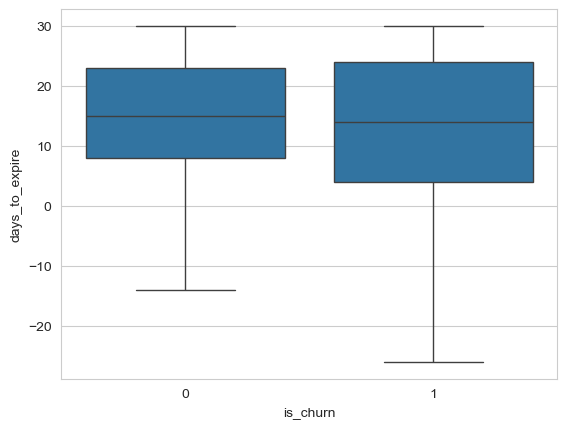

In [65]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_to_expire', showfliers = False)

In [66]:
members_train.head()

,msno,is_churn,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,last_is_auto_renew,last_transaction_date,last_expire,last_is_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,cohort_cutoff_date,city,gender,registered_via,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity,ratio_auto_renew,ratio_cancel
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,0,1,149,149.0,1,0,30,149,149,1,2015-01-26,2015-02-26,0,6,6,25,4.806452,2015-02-01,1.0,NaN,7.0,0.0,0.628527,0.592920,0.568966,0.493279,0.50788,0.494680,1.0,0.0
1,++/Gw1B9K+XOlB3hLTloeUK2QlCa2m+BJ8TrzGf7djI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-13,2015-02-16,0,19,19,15,4.382353,2015-02-01,15.0,male,3.0,0.0,0.670455,0.666667,0.500000,0.469307,0.49009,0.469975,1.0,0.0
2,++/TR7WI15q2ZCtOXmoap7jR+kEhbMVE5swOqsfqpqI=,0,1,149,149.0,1,0,31,149,149,1,2015-01-24,2015-02-25,0,8,8,24,4.656250,2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
3,++2axpngZEynlxNr1+AkwgHHfaEZ/EeOj6Q284RiAkw=,0,1,149,149.0,1,0,30,149,149,1,2015-01-31,2015-02-28,0,1,1,27,5.321429,2015-02-01,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
4,++3FNwZTm6haRgXV0ZRonrNvMxKD9F64lQhIQmQ9wIE=,0,1,149,149.0,1,0,30,149,149,1,2015-01-21,2015-02-21,0,11,11,20,4.806452,2015-02-01,1.0,NaN,7.0,15.0,0.000000,NaN,NaN,0.000000,0.00000,0.000000,1.0,0.0


In [71]:
print("male and churn", members_train.loc[(members_train['gender'] == 'male') & (members_train['is_churn'] == True)].shape[0])
print("male and not churn", members_train.loc[(members_train['gender'] == 'male') & (members_train['is_churn'] == False)].shape[0])

print("female and churn", members_train.loc[(members_train['gender'] == 'female') & (members_train['is_churn'] == True)].shape[0])
print("female and not churn", members_train.loc[(members_train['gender'] == 'female') & (members_train['is_churn'] == False)].shape[0])

print("missing and churn", members_train.loc[(members_train['gender'].isna()) & (members_train['is_churn'] == True)].shape[0])
print("missing and not churn", members_train.loc[(members_train['gender'].isna()) & (members_train['is_churn'] == False)].shape[0])

male and churn 324312
male and not churn 3027249
female and churn 278920
female and not churn 2715727
missing and churn 620316
missing and not churn 7397144


<Axes: xlabel='city', ylabel='Count'>

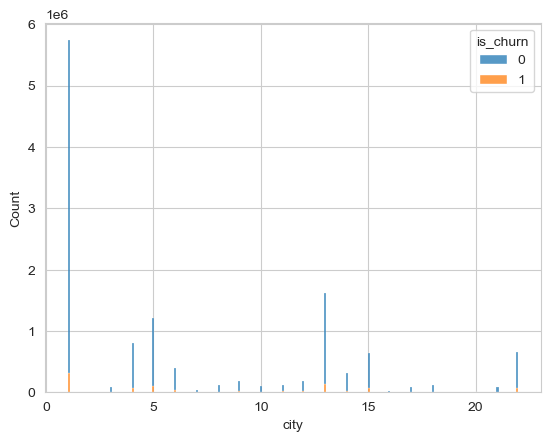

In [72]:
sns.histplot(members_train, x = 'city', hue = 'is_churn', multiple = 'stack')

<Axes: xlabel='is_churn', ylabel='days_since_last_use'>

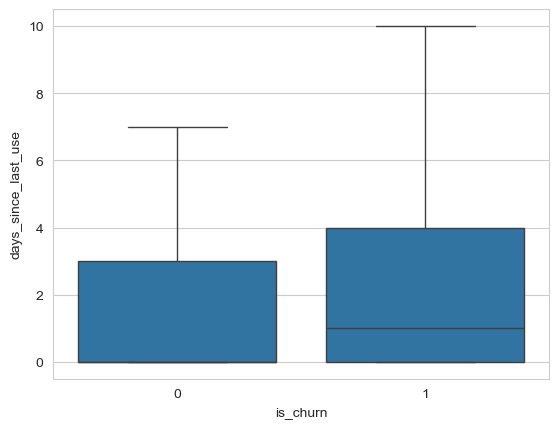

In [74]:
sns.boxplot(members_train, x = 'is_churn', y = 'days_since_last_use', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_25_velocity'>

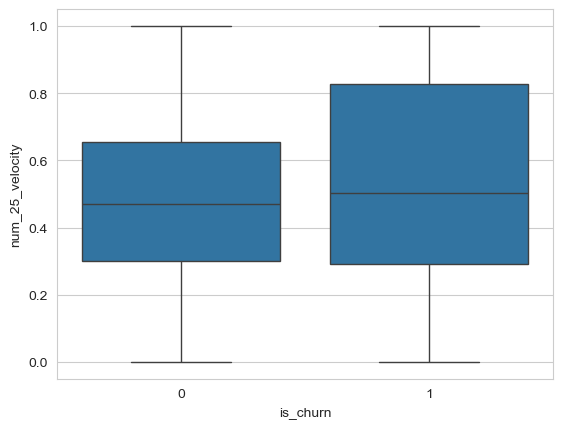

In [75]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_25_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_75_velocity'>

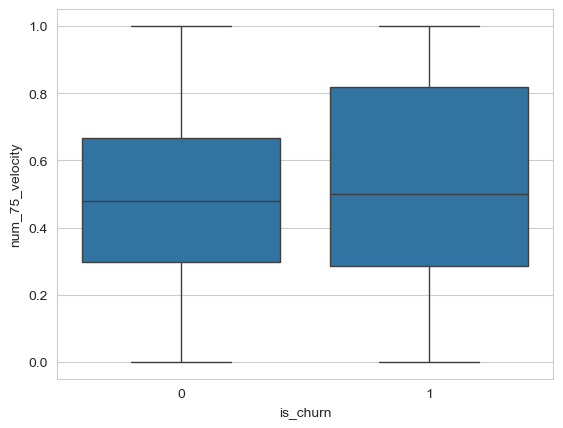

In [76]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_75_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_985_velocity'>

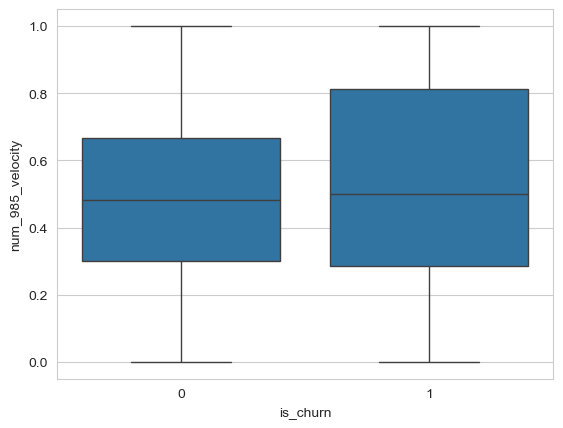

In [77]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_985_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_100_velocity'>

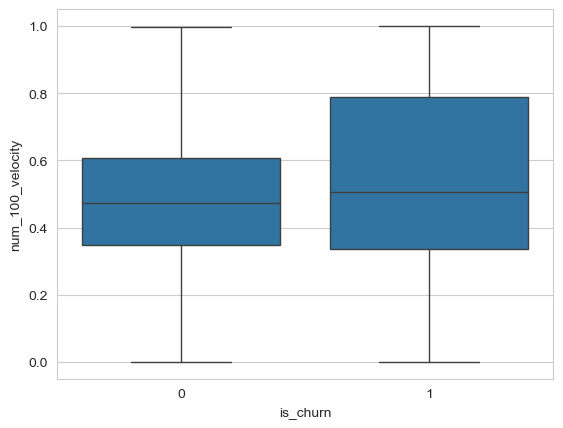

In [78]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_100_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='num_unq_velocity'>

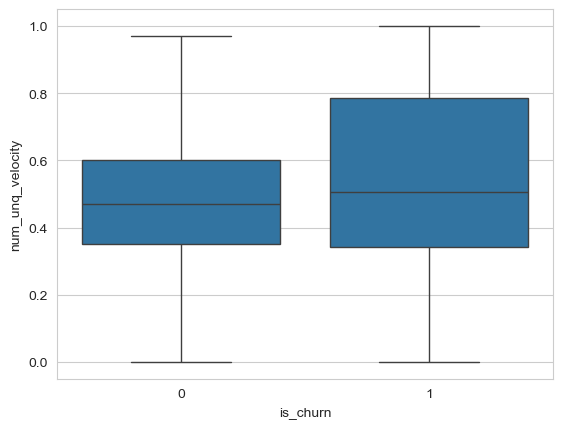

In [79]:
sns.boxplot(members_train, x = 'is_churn', y = 'num_unq_velocity', showfliers = False)

<Axes: xlabel='is_churn', ylabel='total_secs_velocity'>

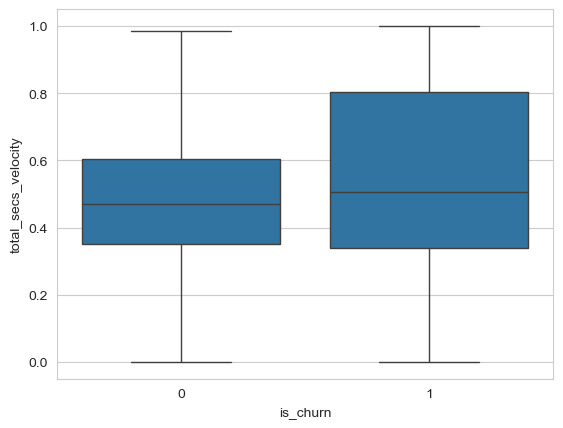

In [80]:
sns.boxplot(members_train, x = 'is_churn', y = 'total_secs_velocity', showfliers = False)

In [81]:
numerical_columns = ['num_transactions', 'total_paid', 'avg_plan_price', 'total_auto_renew', 'total_cancel', 'days_since_first_trans', 'days_since_last_trans', 'days_to_expire', 'avg_payment_per_day', 'last_payment_plan_days', 'last_plan_list_price', 'last_actual_amount_paid', 'days_since_last_use', 'num_25_velocity', 'num_75_velocity', 'num_985_velocity', 'num_100_velocity', 'num_unq_velocity', 'total_secs_velocity', 'ratio_auto_renew', 'ratio_cancel']

In [82]:
members_train[numerical_columns].corr()

,num_transactions,total_paid,avg_plan_price,total_auto_renew,total_cancel,days_since_first_trans,days_since_last_trans,days_to_expire,avg_payment_per_day,last_payment_plan_days,last_plan_list_price,last_actual_amount_paid,days_since_last_use,num_25_velocity,num_75_velocity,num_985_velocity,num_100_velocity,num_unq_velocity,total_secs_velocity,ratio_auto_renew,ratio_cancel
num_transactions,1.000000,0.961577,-0.070788,0.924991,0.369563,0.934997,-0.103138,0.021877,0.095700,-0.064750,-0.039932,-0.060811,0.078430,-0.070286,-0.060307,-0.062767,-0.093205,-0.094336,0.000023,0.209975,0.055796
total_paid,0.961577,1.000000,0.103972,0.869579,0.344744,0.950074,0.046221,0.037143,0.121957,0.082649,0.129052,0.122903,0.045519,-0.069998,-0.060287,-0.062749,-0.093351,-0.094238,0.000059,0.118003,0.041910
avg_plan_price,-0.070788,0.103972,1.000000,-0.098296,0.001487,0.093798,0.822173,-0.076108,0.038059,0.888185,0.902519,0.839786,-0.041106,-0.009531,-0.006637,-0.006575,-0.010534,-0.012034,-0.000043,-0.288935,0.011927
total_auto_renew,0.924991,0.869579,-0.098296,1.000000,0.358388,0.831618,-0.115338,0.027199,0.089988,-0.080018,-0.071023,-0.088631,0.102523,-0.074433,-0.064008,-0.066626,-0.097060,-0.098530,-0.000023,0.473342,0.064801
total_cancel,0.369563,0.344744,0.001487,0.358388,1.000000,0.285696,-0.013014,-0.090495,0.096042,-0.009155,-0.012035,-0.029425,-0.028117,-0.021111,-0.017854,-0.018631,-0.027557,-0.028039,0.000115,0.096945,0.685931
days_since_first_trans,0.934997,0.950074,0.093798,0.831618,0.285696,1.000000,0.067941,0.021418,0.056135,0.098375,0.124859,0.116219,0.082252,-0.065173,-0.056159,-0.058029,-0.087131,-0.088241,0.000046,0.093223,0.027339
days_since_last_trans,-0.103138,0.046221,0.822173,-0.115338,-0.013014,0.067941,1.000000,-0.267760,0.006381,0.890167,0.867926,0.901957,-0.020761,-0.025312,-0.020864,-0.019991,-0.026316,-0.029029,-0.000114,-0.247621,0.001558
days_to_expire,0.021877,0.037143,-0.076108,0.027199,-0.090495,0.021418,-0.267760,1.000000,-0.051252,-0.032411,-0.027317,0.026513,-0.008382,0.044949,0.037101,0.034432,0.039084,0.044007,0.000549,0.041509,-0.153103
avg_payment_per_day,0.095700,0.121957,0.038059,0.089988,0.096042,0.056135,0.006381,-0.051252,1.000000,0.006998,0.032932,0.055952,-0.040994,-0.030270,-0.025008,-0.025363,-0.035942,-0.037110,-0.000017,0.012406,0.111449
last_payment_plan_days,-0.064750,0.082649,0.888185,-0.080018,-0.009155,0.098375,0.890167,-0.032411,0.006998,1.000000,0.976823,0.899383,-0.017413,-0.010480,-0.008365,-0.008226,-0.012473,-0.013889,-0.000051,-0.239840,0.004156


### Comparing the performance of features and their correlation, we pick the features of interest to be: avg_plan_price, days_since_first_trans, days_to_expire, days_since_last_use, ratio_auto_renew, total_sec_velocity, num_unq_velocity, last_is_auto_renew, and last_is_cancel